# LightGBM Waste Forecasting (Multi-Meal)

In [11]:
!pip install lightgbm optuna

In [ ]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

MEALS  = ['breakfast', 'lunch', 'dinner']
TARGET = 'waste_kg'
SECTIONS = ['a', 'b', 'c', 'd']

In [13]:
# 2. Mount Google Drive and set working directory
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    os.chdir('/content/drive/MyDrive/UAB/FDS/campus-waste-intelligence')
    print('Directory changed')
except OSError:
    print("Error: Can't change the Current Working Directory")


Mounted at /content/drive
Directory changed


## 3. Load and Inspect Dataset

In [14]:
def load_and_filter(path: str, meals: list) -> pd.DataFrame:
    """Load raw CSV and retain only the three operational meal types."""
    df = pd.read_csv(path)
    print(f'Raw dataset shape: {df.shape}')
    print('Meal values:', df['meal'].unique())
    df = df[df['meal'].isin(meals)].copy()
    print(f'After filtering to {meals}: {df.shape}')
    return df

df_raw = load_and_filter('data/waste_features_xgb.csv', MEALS)
df_raw.head()


Raw dataset shape: (2506, 33)
Meal values: ['lunch' 'breakfast' 'closed' 'dinner']
After filtering to ['breakfast', 'lunch', 'dinner']: (1813, 33)


,meal,waste_kg,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg,foot_traffic,is_holiday,has_special_event,year,month,...,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_max_7,section_encoded,section_a,section_b,section_c,section_d
0,lunch,5.17,2.74,1.75,0.68,102.00,0,1,2025,1,...,0.18,2.262857,2.102857,2.249257,5.58,0,True,False,False,False
1,breakfast,4.26,1.74,1.27,1.24,46.25,0,1,2025,1,...,3.18,2.854286,2.396429,2.133197,5.58,0,True,False,False,False
3,dinner,2.72,1.72,0.75,0.25,75.00,0,1,2025,1,...,0.06,2.147143,2.390000,1.978819,5.17,0,True,False,False,False
4,lunch,6.07,3.12,2.06,0.89,138.00,0,1,2025,1,...,1.50,2.842857,2.810000,2.401317,6.07,0,True,False,False,False
5,breakfast,2.96,1.21,0.89,0.85,46.00,0,1,2025,1,...,1.82,3.244286,2.786429,2.090940,6.07,0,True,False,False,False


## 4. Preprocess Data

In [ ]:
def identify_section(row) -> str:
    """Return the section label (a–d) for a given row."""
    for s in SECTIONS:
        if row.get(f'section_{s}', False):
            return s
    return None


def compute_lag_rolling_features(df: pd.DataFrame, target: str,
                                  group_key: list) -> pd.DataFrame:
    for lag in [1, 7, 14, 28]:
        df[f'lag_{lag}'] = df.groupby(group_key)[target].shift(lag)

    df['rolling_mean_7']  = df.groupby(group_key)[target].transform(
        lambda x: x.shift(1).rolling(7,  min_periods=1).mean())
    df['rolling_mean_14'] = df.groupby(group_key)[target].transform(
        lambda x: x.shift(1).rolling(14, min_periods=1).mean())
    df['rolling_std_7']   = df.groupby(group_key)[target].transform(
        lambda x: x.shift(1).rolling(7,  min_periods=1).std().fillna(0))
    df['rolling_max_7']   = df.groupby(group_key)[target].transform(
        lambda x: x.shift(1).rolling(7,  min_periods=1).max())
    return df


def split_by_section(df: pd.DataFrame, sections: list) -> dict:
    """Return {section_label: DataFrame} with indicator/encoded columns dropped."""
    drop_cols = [f'section_{s}' for s in sections] + ['section_encoded', 'section']
    result = {}
    for sec in sections:
        sdf = df[df['section'] == sec].copy()
        sdf = sdf.drop(columns=drop_cols, errors='ignore')
        result[sec] = sdf
        print(f'Section {sec.upper()}: {len(sdf)} rows, '
              f'{sdf["meal_type"].value_counts().to_dict()}')
    return result


df_raw['date']     = pd.to_datetime(df_raw[['year', 'month', 'day']])
df_raw['section']  = df_raw.apply(identify_section, axis=1)
df_raw             = df_raw.rename(columns={'meal': 'meal_type'})
df_raw             = df_raw.sort_values(['section', 'date', 'meal_type']).reset_index(drop=True)

GROUP_KEY = ['section', 'meal_type']
df_raw    = compute_lag_rolling_features(df_raw, TARGET, GROUP_KEY)
df_raw    = df_raw.dropna(subset=[f'lag_{l}' for l in [1, 7, 14, 28]]).reset_index(drop=True)
print(f'After preprocessing: {df_raw.shape}')

section_data = split_by_section(df_raw, SECTIONS)


After preprocessing: (1477, 35)
Section A: 371 rows, {'dinner': 127, 'breakfast': 125, 'lunch': 119}
Section B: 372 rows, {'dinner': 130, 'breakfast': 125, 'lunch': 117}
Section C: 372 rows, {'dinner': 131, 'breakfast': 129, 'lunch': 112}
Section D: 362 rows, {'dinner': 131, 'breakfast': 124, 'lunch': 107}


## 5. Define Features and Target

`meal_type` is kept as a **LightGBM categorical feature** (encoded via `category` dtype).
`date` is dropped before training.


In [ ]:
def get_X_y(data: pd.DataFrame, target: str = TARGET):
    X = data.drop(columns=[target, 'date'], errors='ignore')
    y = data[target]
    cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].astype('category')
    return X, y

X_a, y_a = get_X_y(section_data['a'])
print(f'Features shape: {X_a.shape}')
print('Feature columns:', list(X_a.columns))
print('Categorical features:', X_a.select_dtypes('category').columns.tolist())


Features shape: (371, 27)
Feature columns: ['meal_type', 'waste_organic_kg', 'waste_recyclable_kg', 'waste_landfill_kg', 'foot_traffic', 'is_holiday', 'has_special_event', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'rolling_max_7']
Categorical features: ['meal_type']


## 6. Time-Based Train/Test Split

The last **30 calendar days** (≈ 90 rows for 3 meals × 30 days) are reserved for testing.
The split is date-based so all meals of a given day remain in the same partition.


In [17]:
TEST_DAYS = 30

def make_splits(section_data: dict, test_days: int = TEST_DAYS) -> dict:
    """Return {section: {'train': df, 'test': df}} for all sections."""
    splits = {}
    for sec, data in section_data.items():
        data = data.sort_values('date').reset_index(drop=True)
        unique_dates = data['date'].drop_duplicates().sort_values()
        cutoff       = unique_dates.iloc[-test_days]
        train = data[data['date'] < cutoff].copy()
        test  = data[data['date'] >= cutoff].copy()
        splits[sec] = {'train': train, 'test': test}
        print(f'Section {sec.upper()} | Train: {len(train)} rows '
              f'({train["date"].nunique()} days) | '
              f'Test: {len(test)} rows ({test["date"].nunique()} days)')
    return splits


splits = make_splits(section_data)


Section A | Train: 292 rows (113 days) | Test: 79 rows (30 days)
Section B | Train: 294 rows (113 days) | Test: 78 rows (30 days)
Section C | Train: 297 rows (112 days) | Test: 75 rows (30 days)
Section D | Train: 288 rows (112 days) | Test: 74 rows (30 days)


## 7. Evaluation Helpers

In [18]:
def evaluate_model(model, X_test, y_test):
    """Return (RMSE, MAE, MAPE, R²) for a fitted model."""
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) /
                           np.where(y_test == 0, 1e-9, y_test))) * 100
    r2   = r2_score(y_test, pred)
    return rmse, mae, mape, r2


def evaluate_by_meal(model, test_data: pd.DataFrame) -> list:
    """Return per-meal metric dicts for a fitted model."""
    rows = []
    for meal in MEALS:
        mdf = test_data[test_data['meal_type'] == meal]
        if len(mdf) == 0:
            continue
        Xm, ym = get_X_y(mdf)
        rmse, mae, mape, r2 = evaluate_model(model, Xm, ym)
        rows.append({'meal': meal, 'RMSE': rmse, 'MAE': mae,
                     'MAPE': mape, 'R2': r2})
    return rows


## 8. Baseline LightGBM Model (Default Parameters)

Train with factory defaults to establish a performance reference.


In [ ]:
def train_lgb_baseline(X_train, y_train, cat_cols=None):
    """Fit LightGBM with factory-default hyperparameters."""
    model = lgb.LGBMRegressor(
        objective='regression',
        random_state=RANDOM_SEED,
        verbosity=-1,
        n_jobs=-1,
    )
    fit_params = {}
    if cat_cols:
        fit_params['categorical_feature'] = cat_cols
    model.fit(X_train, y_train, **fit_params)
    return model


baseline_results = []

for sec in SECTIONS:
    train = splits[sec]['train']
    test  = splits[sec]['test']
    X_train, y_train = get_X_y(train)
    X_test,  y_test  = get_X_y(test)
    cat_cols = X_train.select_dtypes('category').columns.tolist()

    model = train_lgb_baseline(X_train, y_train, cat_cols)
    rmse, mae, mape, r2 = evaluate_model(model, X_test, y_test)
    baseline_results.append({'section': sec.upper(), 'meal': 'overall',
                              'RMSE': rmse, 'MAE': mae,
                              'MAPE': mape, 'R2': r2})
    for row in evaluate_by_meal(model, test):
        row['section'] = sec.upper()
        baseline_results.append(row)

    # Persist baseline
    with open(f'models/lightgbm_optimized/baseline_section_{sec}.pkl', 'wb') as f:
        pickle.dump(model, f)

baseline_df = pd.DataFrame(baseline_results)
print('Baseline Performance')
print(baseline_df.to_string(index=False))

=== Baseline Performance ===
section      meal     RMSE      MAE     MAPE       R2
      A   overall 0.302704 0.212030 6.161335 0.983482
      A breakfast 0.247247 0.156331 6.225095 0.967865
      A     lunch 0.422044 0.325918 8.483020 0.974963
      A    dinner 0.224294 0.175552 4.033968 0.991057
      B   overall 1.346583 0.433376 5.476226 0.869226
      B breakfast 0.101830 0.075096 3.437843 0.993715
      B     lunch 2.312452 1.017718 8.912012 0.753430
      B    dinner 0.277372 0.197869 4.033040 0.987399
      C   overall 0.590398 0.214263 3.530270 0.960396
      C breakfast 0.132674 0.090263 2.915560 0.993932
      C     lunch 1.011966 0.430054 4.024459 0.917571
      C    dinner 0.207998 0.134302 3.665164 0.990870
      D   overall 0.836059 0.351959 5.304417 0.924603
      D breakfast 0.300148 0.162362 4.252469 0.975319
      D     lunch 1.453976 0.794574 8.248137 0.834156
      D    dinner 0.180842 0.142720 3.711845 0.993122


## 9. Cross-Validation and Hyperparameter Optimisation

OptunaBayesian search with `TimeSeriesSplit` (5 folds).

Search space: `num_leaves`, `n_estimators`, `learning_rate`, `min_child_samples`,
`subsample`, `colsample_bytree`, `reg_lambda`, `reg_alpha`.

Up to 50 trials per section.


In [ ]:
def lgb_objective(trial, X_train, y_train, cat_cols, cv_splits=5):
    """Optuna objective: minimise CV-RMSE for LightGBM."""
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'objective':         'regression',
        'random_state':      RANDOM_SEED,
        'verbosity':         -1,
        'n_jobs':            -1,
    }

    tscv        = TimeSeriesSplit(n_splits=cv_splits)
    rmse_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        Xtr, Xval = X_train.iloc[train_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[train_idx], y_train.iloc[val_idx]
        m = lgb.LGBMRegressor(**params)
        m.fit(Xtr, ytr, categorical_feature=cat_cols,
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)],
              eval_set=[(Xval, yval)])
        pred = m.predict(Xval)
        rmse_scores.append(np.sqrt(mean_squared_error(yval, pred)))

    return np.mean(rmse_scores)


N_TRIALS    = 50
best_models = {}
study_logs  = {}

for sec in SECTIONS:
    print(f"Optimising Section {sec.upper()}")
    train    = splits[sec]['train']
    X_train, y_train = get_X_y(train)
    cat_cols = X_train.select_dtypes('category').columns.tolist()

    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    )

    def obj_wrapper(trial):
        return lgb_objective(trial, X_train, y_train, cat_cols)

    study.optimize(obj_wrapper, n_trials=N_TRIALS, show_progress_bar=True)
    study_logs[sec] = study.trials_dataframe()

    best_params = study.best_params
    print(f'Best params for Section {sec.upper()}: {best_params}')

    # Re-train on full training set with best params
    final_model = lgb.LGBMRegressor(
        **best_params,
        objective='regression',
        random_state=RANDOM_SEED,
        verbosity=-1,
        n_jobs=-1,
    )
    final_model.fit(X_train, y_train, categorical_feature=cat_cols)
    best_models[sec] = final_model

    # Persist tuned model and params
    with open(f'models/lightgbm_optimized/tuned_section_{sec}.pkl', 'wb') as f:
        pickle.dump(final_model, f)
    with open(f'models/lightgbm_optimized/best_params_section_{sec}.pkl', 'wb') as f:
        pickle.dump(best_params, f)

    # Quick test-set evaluation
    test = splits[sec]['test']
    X_test, y_test = get_X_y(test)
    rmse, mae, mape, r2 = evaluate_model(final_model, X_test, y_test)
    print(f'Test | RMSE: {rmse:.4f}  MAE: {mae:.4f}  '
          f'MAPE: {mape:.2f}%  R²: {r2:.4f}')

print('\nOptimisation completed for all sections.')



Optimising Section A


  0%|          | 0/50 [00:00<?, ?it/s]

Best params for Section A: {'num_leaves': 129, 'n_estimators': 400, 'learning_rate': 0.035076459793632664, 'min_child_samples': 5, 'subsample': 0.7881065472372825, 'colsample_bytree': 0.8834063075700739, 'reg_lambda': 2.258787190981602, 'reg_alpha': 0.24930482777551832}
Test | RMSE: 0.2279  MAE: 0.1238  MAPE: 3.21%  R²: 0.9906

Optimising Section B


  0%|          | 0/50 [00:00<?, ?it/s]

Best params for Section B: {'num_leaves': 129, 'n_estimators': 400, 'learning_rate': 0.035076459793632664, 'min_child_samples': 5, 'subsample': 0.7881065472372825, 'colsample_bytree': 0.8834063075700739, 'reg_lambda': 2.258787190981602, 'reg_alpha': 0.24930482777551832}
Test | RMSE: 0.9471  MAE: 0.2681  MAPE: 3.62%  R²: 0.9353

Optimising Section C


  0%|          | 0/50 [00:00<?, ?it/s]

Best params for Section C: {'num_leaves': 141, 'n_estimators': 250, 'learning_rate': 0.06536388112674597, 'min_child_samples': 5, 'subsample': 0.6005800047171014, 'colsample_bytree': 0.7049193313408516, 'reg_lambda': 5.577701715879632, 'reg_alpha': 0.11553213211102557}
Test | RMSE: 0.3242  MAE: 0.1584  MAPE: 3.14%  R²: 0.9881

Optimising Section D


  0%|          | 0/50 [00:00<?, ?it/s]

Best params for Section D: {'num_leaves': 133, 'n_estimators': 350, 'learning_rate': 0.05893355393218917, 'min_child_samples': 5, 'subsample': 0.8671032800761714, 'colsample_bytree': 0.8910950214684843, 'reg_lambda': 7.300451562386887, 'reg_alpha': 0.31950954540269344}
Test | RMSE: 0.5083  MAE: 0.1794  MAPE: 2.89%  R²: 0.9721

Optimisation completed for all sections.


## 10. Performance Comparison

In [ ]:
final_results = []

for sec in SECTIONS:
    test = splits[sec]['test']
    X_test, y_test = get_X_y(test)

    # Baseline
    with open(f'models/lightgbm_optimized/baseline_section_{sec}.pkl', 'rb') as f:
        baseline_model = pickle.load(f)
    b_rmse, b_mae, b_mape, b_r2 = evaluate_model(baseline_model, X_test, y_test)

    # Tuned
    tuned_model = best_models[sec]
    t_rmse, t_mae, t_mape, t_r2 = evaluate_model(tuned_model, X_test, y_test)

    for model_name, rmse, mae, mape, r2 in [
        ('Baseline',       b_rmse, b_mae, b_mape, b_r2),
        ('Tuned (Optuna)', t_rmse, t_mae, t_mape, t_r2),
    ]:
        final_results.append({'section': sec.upper(), 'model': model_name,
                               'meal': 'overall', 'RMSE': rmse,
                               'MAE': mae, 'MAPE': mape, 'R2': r2})

    for row in evaluate_by_meal(tuned_model, test):
        row.update({'section': sec.upper(), 'model': 'Tuned (Optuna)'})
        final_results.append(row)

results_df = pd.DataFrame(final_results)
print('Performance Comparison')
print(results_df.to_string(index=False))

results_df.to_csv('metrics/lightgbm_model_comparison.csv', index=False)

=== Final Performance Comparison ===
section          model      meal     RMSE      MAE     MAPE       R2
      A       Baseline   overall 0.302704 0.212030 6.161335 0.983482
      A Tuned (Optuna)   overall 0.227884 0.123842 3.208575 0.990639
      A Tuned (Optuna) breakfast 0.132111 0.078719 2.900505 0.990825
      A Tuned (Optuna)     lunch 0.339492 0.188642 4.240775 0.983800
      A Tuned (Optuna)    dinner 0.188933 0.118585 2.650940 0.993654
      B       Baseline   overall 1.346583 0.433376 5.476226 0.869226
      B Tuned (Optuna)   overall 0.947056 0.268097 3.624335 0.935315
      B Tuned (Optuna) breakfast 0.060870 0.047868 2.392561 0.997754
      B Tuned (Optuna)     lunch 1.610362 0.556929 4.932002 0.880425
      B Tuned (Optuna)    dinner 0.295531 0.188665 3.465878 0.985695
      C       Baseline   overall 0.590398 0.214263 3.530270 0.960396
      C Tuned (Optuna)   overall 0.324245 0.158401 3.137849 0.988055
      C Tuned (Optuna) breakfast 0.098199 0.077334 2.959335 0.9966

## 11. 7-Day Forecast (Breakfast, Lunch, Dinner)

In [ ]:
def update_temporal_features(row: pd.Series, next_date: pd.Timestamp) -> pd.Series:
    row = row.copy()
    row['date']         = next_date
    row['year']         = next_date.year
    row['month']        = next_date.month
    row['day']          = next_date.day
    row['day_of_week']  = next_date.dayofweek
    row['day_of_year']  = next_date.dayofyear
    row['week_of_year'] = int(next_date.isocalendar().week)
    row['quarter']      = next_date.quarter
    row['is_weekend']   = int(next_date.dayofweek >= 5)
    row['dow_sin']      = np.sin(2 * np.pi * next_date.dayofweek / 7)
    row['dow_cos']      = np.cos(2 * np.pi * next_date.dayofweek / 7)
    row['doy_sin']      = np.sin(2 * np.pi * next_date.dayofyear / 365)
    row['doy_cos']      = np.cos(2 * np.pi * next_date.dayofyear / 365)
    return row


def recompute_lags(temp_df: pd.DataFrame, target: str = TARGET) -> pd.DataFrame:
    for lag in [1, 7, 14, 28]:
        temp_df[f'lag_{lag}'] = temp_df[target].shift(lag)
    temp_df['rolling_mean_7']  = temp_df[target].shift(1).rolling(7,  min_periods=1).mean()
    temp_df['rolling_mean_14'] = temp_df[target].shift(1).rolling(14, min_periods=1).mean()
    temp_df['rolling_std_7']   = temp_df[target].shift(1).rolling(7,  min_periods=1).std().fillna(0)
    temp_df['rolling_max_7']   = temp_df[target].shift(1).rolling(7,  min_periods=1).max()
    return temp_df


def forecast_next_week(model, history_df: pd.DataFrame,
                       horizon: int = 7, target: str = TARGET) -> dict:
    MAX_LOOKBACK = 28
    forecasts    = {meal: [] for meal in MEALS}

    history_df = history_df.sort_values(['date', 'meal_type']).reset_index(drop=True)
    last_date  = history_df['date'].max()

    meal_histories = {
        meal: history_df[history_df['meal_type'] == meal].copy()
        for meal in MEALS
    }

    for i in range(1, horizon + 1):
        next_date = last_date + pd.Timedelta(days=i)

        for meal in MEALS:
            meal_hist = meal_histories[meal]

            # Build new row with static context from the last known row
            new_row           = meal_hist.iloc[-1:].copy()
            new_row           = new_row.apply(
                lambda r: update_temporal_features(r, next_date), axis=1)
            new_row[target]   = np.nan
            new_row['meal_type'] = meal

            # Concatenate with recent history and recalculate features
            temp = pd.concat([meal_hist.iloc[-MAX_LOOKBACK:], new_row],
                             ignore_index=True)
            temp = recompute_lags(temp, target)

            # Predict
            X_pred = temp.iloc[-1:].drop(columns=[target, 'date'], errors='ignore')
            for col in X_pred.select_dtypes(include=['object', 'string']).columns:
                X_pred[col] = X_pred[col].astype('category')
            predicted = float(model.predict(X_pred)[0])
            forecasts[meal].append(predicted)

            # Update history with prediction
            new_row[target] = predicted
            meal_histories[meal] = pd.concat([meal_hist, new_row],
                                             ignore_index=True)

    return forecasts


In [ ]:
weekly_forecasts = {}

for sec in SECTIONS:
    with open(f'models/lightgbm_optimized/tuned_section_{sec}.pkl', 'rb') as f:
        model = pickle.load(f)

    train_history = splits[sec]['train']
    forecasts     = forecast_next_week(model, train_history, horizon=7)
    weekly_forecasts[sec.upper()] = forecasts

    print(f'\nSection {sec.upper()} 7-day forecast:')
    for meal, preds in forecasts.items():
        print(f'  {meal:10s}: {[round(p, 2) for p in preds]}')

# Persist
forecast_rows = [
    {'section': sec, 'meal_type': meal, 'day': f'Day_{d}', 'forecast_kg': val}
    for sec, meal_dict in weekly_forecasts.items()
    for meal, preds in meal_dict.items()
    for d, val in enumerate(preds, start=1)
]
forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv('metrics/lightgbm_weekly_forecasts.csv', index=False)
print('\nWeekly forecasts saved to lightgbm_weekly_forecasts.csv')



Section A 7-day forecast:
  breakfast : [1.31, 1.31, 1.32, 1.32, 1.31, 1.32, 1.32]
  lunch     : [5.63, 5.61, 5.64, 5.65, 5.66, 5.69, 5.65]
  dinner    : [1.64, 1.64, 1.66, 1.64, 1.65, 1.65, 1.64]

Section B 7-day forecast:
  breakfast : [2.57, 2.57, 2.56, 2.57, 2.58, 2.58, 2.57]
  lunch     : [5.94, 5.94, 5.91, 5.95, 5.91, 5.92, 5.95]
  dinner    : [7.9, 7.87, 7.88, 7.93, 7.95, 7.89, 7.95]

Section C 7-day forecast:
  breakfast : [4.22, 4.1, 4.09, 4.09, 4.09, 4.11, 4.1]
  lunch     : [13.69, 13.42, 13.53, 13.45, 13.39, 13.39, 13.39]
  dinner    : [10.41, 10.14, 10.18, 10.14, 10.15, 10.2, 10.21]

Section D 7-day forecast:
  breakfast : [1.03, 1.06, 1.04, 1.05, 1.03, 1.05, 1.07]
  lunch     : [2.06, 2.08, 2.06, 2.08, 2.04, 2.06, 2.05]
  dinner    : [2.46, 2.48, 2.47, 2.46, 2.48, 2.46, 2.45]

Weekly forecasts saved to lightgbm_weekly_forecasts.csv


## 12. Reload Saved Models and Verify Predictions

In [ ]:
for sec in SECTIONS:
    path = f'models/lightgbm_optimized/tuned_section_{sec}.pkl'
    with open(path, 'rb') as f:
        reloaded = pickle.load(f)

    test = splits[sec]['test']
    X_test, y_test = get_X_y(test)
    in_mem  = evaluate_model(best_models[sec],  X_test, y_test)[0]
    reloaded_rmse = evaluate_model(reloaded, X_test, y_test)[0]
    match = 'Match' if abs(in_mem - reloaded_rmse) < 1e-9 else 'Mismatch'
    print(f'Section {sec.upper()} | RMSE: {in_mem:.6f} | '
          f'Reloaded RMSE: {reloaded_rmse:.6f} | {match}')


=== Reload & Verify ===
Section A | In-memory RMSE: 0.227884 | Reloaded RMSE: 0.227884 | ✓ Match
Section B | In-memory RMSE: 0.947056 | Reloaded RMSE: 0.947056 | ✓ Match
Section C | In-memory RMSE: 0.324245 | Reloaded RMSE: 0.324245 | ✓ Match
Section D | In-memory RMSE: 0.508273 | Reloaded RMSE: 0.508273 | ✓ Match


## 13. Generalisation Check

Compare cross-validation RMSE versus hold-out test RMSE.


In [ ]:
print('Generalization Check')
for sec in SECTIONS:
    best_val_rmse = study_logs[sec]['value'].min()
    test_rmse = results_df[
        (results_df['section'] == sec.upper()) &
        (results_df['model']   == 'Tuned (Optuna)') &
        (results_df['meal']    == 'overall')
    ]['RMSE'].values[0]
    diff   = abs(best_val_rmse - test_rmse)
    status = ('Good generalisation.'
               if diff < 0.5
               else 'Possible overfitting — consider more regularisation.')
    print(f'Section {sec.upper()} | CV RMSE: {best_val_rmse:.4f} | '
          f'Test RMSE: {test_rmse:.4f} | Diff: {diff:.4f} → {status}')


=== Generalisation Check ===
Section A | CV RMSE: 0.4670 | Test RMSE: 0.2279 | Diff: 0.2392 → Good generalisation.
Section B | CV RMSE: 0.3242 | Test RMSE: 0.9471 | Diff: 0.6229 → Possible overfitting — consider more regularisation.
Section C | CV RMSE: 0.4426 | Test RMSE: 0.3242 | Diff: 0.1183 → Good generalisation.
Section D | CV RMSE: 0.3891 | Test RMSE: 0.5083 | Diff: 0.1192 → Good generalisation.


## 14. Visualise Forecasts: Baseline vs Tuned, by Meal Type


In [26]:
all_comparison = {}

for sec in SECTIONS:
    train_data = splits[sec]['train']

    with open(f'models/lightgbm_optimized/baseline_section_{sec}.pkl', 'rb') as f:
        baseline_model = pickle.load(f)
    base_preds = forecast_next_week(baseline_model, train_data.copy(), horizon=7)

    with open(f'models/lightgbm_optimized/tuned_section_{sec}.pkl', 'rb') as f:
        tuned_model = pickle.load(f)
    tuned_preds = forecast_next_week(tuned_model, train_data.copy(), horizon=7)

    all_comparison[sec.upper()] = {'Baseline': base_preds, 'Tuned': tuned_preds}

print('Forecasts compiled for all sections.')


Forecasts compiled for all sections.


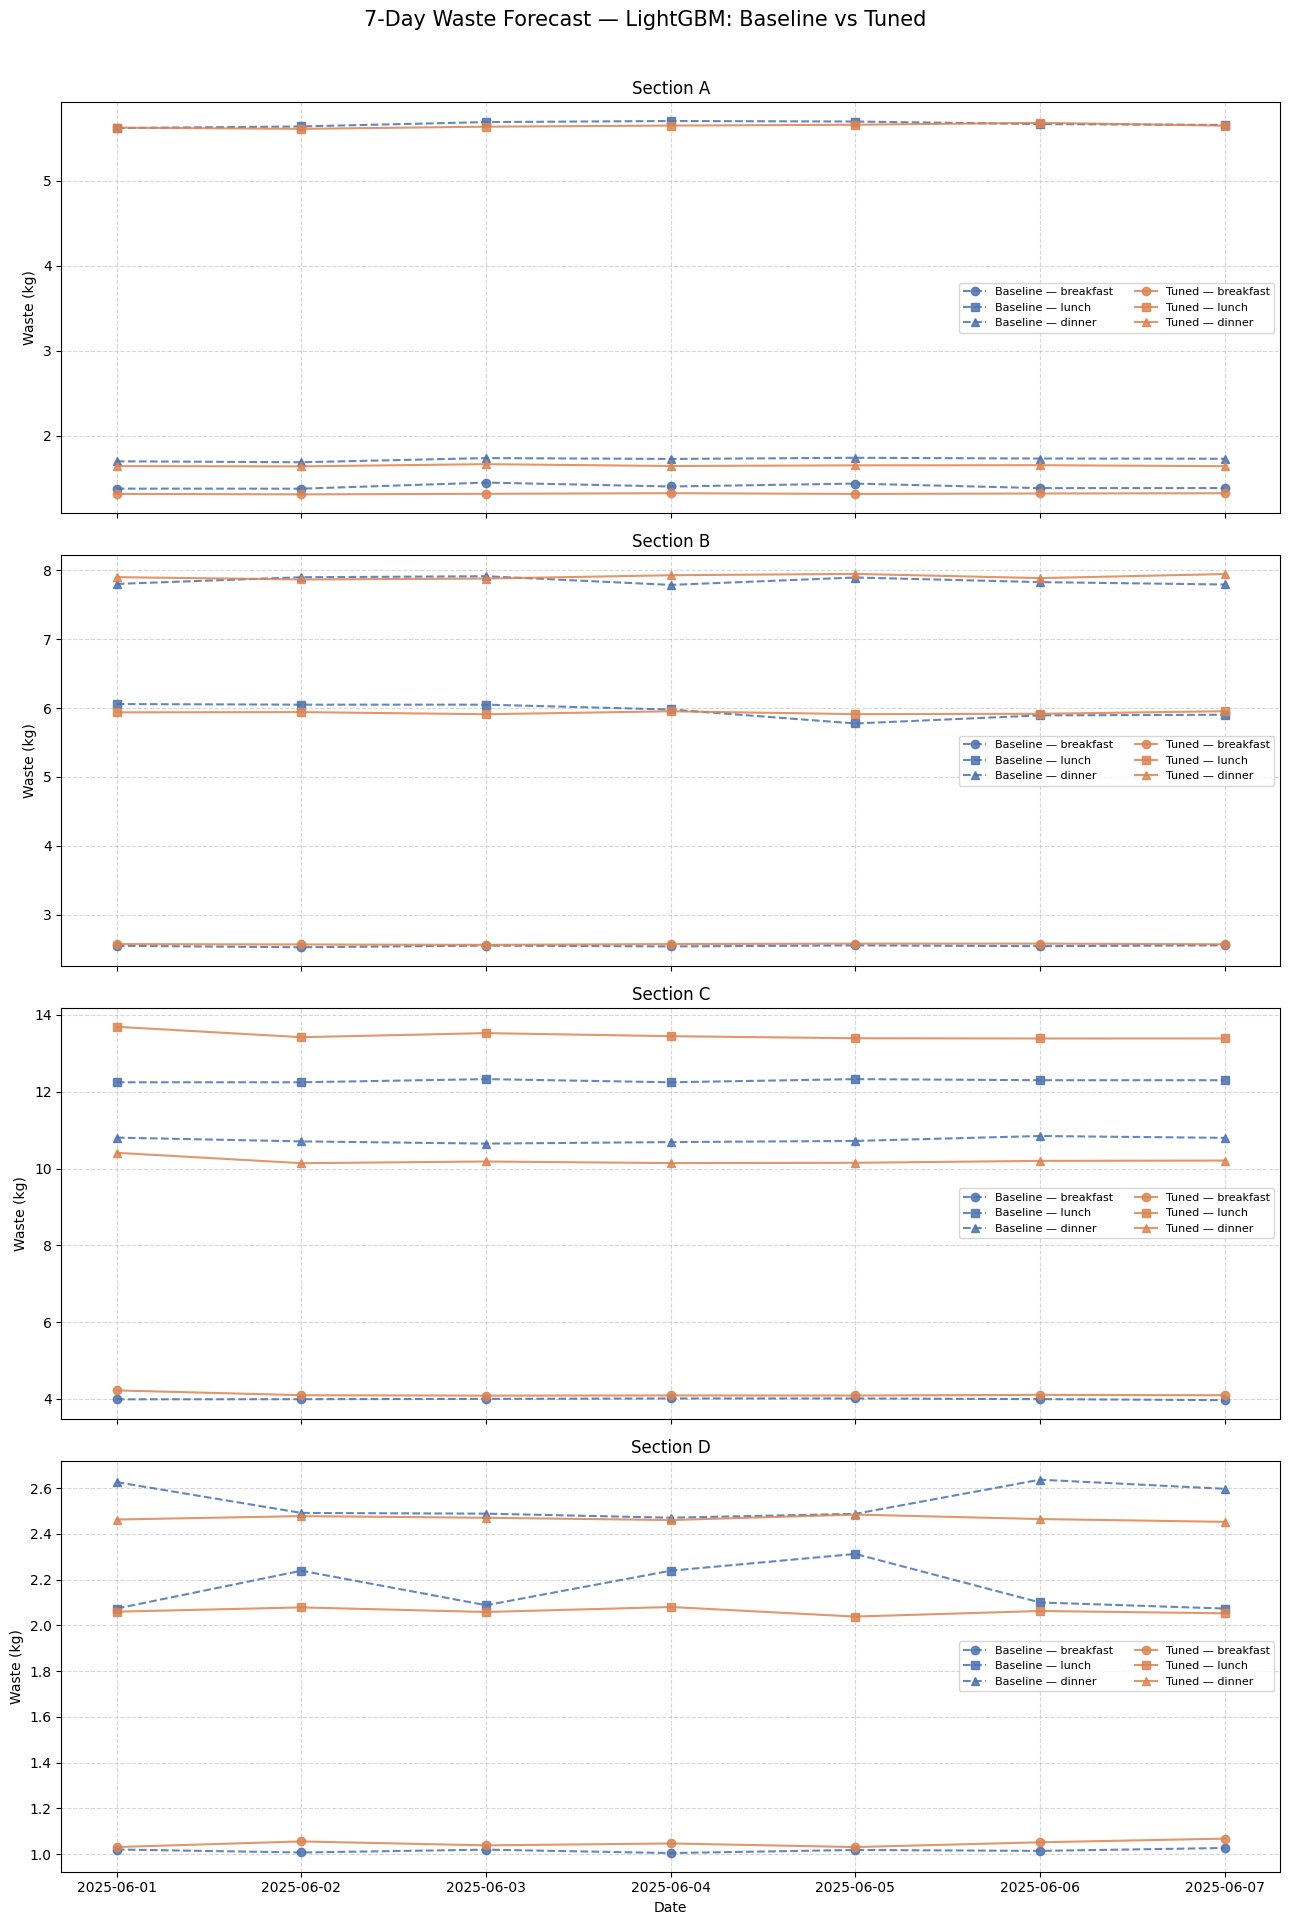

Figure saved to lightgbm_forecast_comparison.png


In [ ]:
last_train_date = splits['a']['train']['date'].max()
forecast_dates  = pd.date_range(start=last_train_date + pd.Timedelta(days=1), periods=7)

plot_rows = [
    {'Date': date, 'Section': sec, 'Model': mname, 'Meal': meal, 'Forecast': val}
    for sec, model_dict in all_comparison.items()
    for mname, meal_dict in model_dict.items()
    for meal, preds in meal_dict.items()
    for date, val in zip(forecast_dates, preds)
]
plot_df = pd.DataFrame(plot_rows)

meal_styles   = {'breakfast': 'o', 'lunch': 's', 'dinner': '^'}
model_palette = {'Baseline': '#4C72B0', 'Tuned': '#DD8452'}

fig, axes = plt.subplots(len(SECTIONS), 1, figsize=(13, 5 * len(SECTIONS)), sharex=True)
fig.suptitle('7-Day Waste Forecast — LightGBM: Baseline vs Tuned', fontsize=15)

for i, sec_key in enumerate(SECTIONS):
    ax  = axes[i]
    sub = plot_df[plot_df['Section'] == sec_key.upper()]
    for mname in ['Baseline', 'Tuned']:
        for meal in MEALS:
            s = sub[(sub['Model'] == mname) & (sub['Meal'] == meal)]
            ax.plot(s['Date'], s['Forecast'],
                    marker=meal_styles[meal],
                    color=model_palette[mname],
                    linestyle='-' if mname == 'Tuned' else '--',
                    alpha=0.85,
                    label=f'{mname} — {meal}')
    ax.set_title(f'Section {sec_key.upper()}')
    ax.set_ylabel('Waste (kg)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel('Date')
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('figures/lightgbm_forecast_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to lightgbm_forecast_comparison.png')
